# Error analysis 2: acoustic factors, background errors and confusion

This notebook keeps three analysis scopes separate.

**A. Cross-corpus acoustic analysis (`sp5`)**: BioDCASE/HumbugDB → MIRU-indoor/outdoor. Four settings are analyzed: BioDCASE → Indoor, BioDCASE → Outdoor, HumbugDB → Indoor, HumbugDB → Outdoor. SNR/RMS sections use **true mosquito segments only**.

**B. Background false positives (`sp5`)**: the same four cross-corpus MIRU settings, but using **true Noise segments only**.

**C. Species+sex confusion (`sx9`)**: MIRU tests only, split into same-environment, indoor↔outdoor transfer, and mixed indoor+outdoor training.

SNR/RMS results are descriptive associations, not causal claims.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

ROOT=Path("/home/mosbnet/mosdet/mosbeatnet_main"); OUTPUT=ROOT/"output"; META_DIR=ROOT/"data"/"simulated_data"/"gen_xdomain"/"metadata"; OUT_DIR=ROOT/"data"/"err_analytic"
OUT_DIR.mkdir(parents=True,exist_ok=True); TARGET_MODEL="mosbeatnet_v2"
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,"axes.spines.right":False})

def train_source(x):
    x=str(x).lower()
    if "exp1_indoor" in x: return "MIRU-indoor"
    if "exp2_outdoor" in x: return "MIRU-outdoor"
    if "exp3_humbug" in x: return "HumbugDB"
    if "exp4_biodcase" in x: return "BioDCASE"
    if "exp5_indoor_outdoor" in x: return "MIRU indoor+outdoor"
    if "exp6_all_sources" in x: return "All sources"
    return "Other"

def test_source(x):
    x=str(x).lower()
    if "biodcase" in x: return "BioDCASE"
    if "humbug" in x: return "HumbugDB"
    if "indoor" in x: return "MIRU-indoor"
    if "outdoor" in x: return "MIRU-outdoor"
    return "Other"

def task_of(exp): return "species_sex" if str(exp).endswith("_sx9") else "species"
def is_noise(x): return str(x).strip().lower() in {"noise","background","bg","-","","nan","none","na","n/a","<na>"}
def save(name): plt.savefig(OUT_DIR/f"{name}.png",dpi=200,bbox_inches="tight")
def short_setting(x): return str(x).replace("MIRU-indoor","Indoor").replace("MIRU-outdoor","Outdoor").replace("MIRU indoor+outdoor","Mixed")


## 1. Load latest segment predictions

For each experiment × model × seed, the latest run containing evaluated segment predictions is used. `_ws` experiments and pooled `all_domains` predictions are excluded to avoid duplicate segment rows.

In [2]:
frames=[]
for exp in sorted(OUTPUT.glob("xdomain_exp*")):
    if "_ws" in exp.name or not exp.is_dir(): continue
    for model in exp.iterdir():
        if not model.is_dir(): continue
        for seed in model.glob("seed_*"):
            runs=[]
            for run in seed.glob("run_*"):
                files=[p for p in sorted((run/"evaluation"/"best_macro_f1").glob("*/segment_predictions.csv")) if p.parent.name!="all_domains"]
                if files: runs.append((run,files))
            if not runs: continue
            run,files=sorted(runs,key=lambda z:z[0].name)[-1]
            for p in files:
                d=pd.read_csv(p,low_memory=False)
                if d.empty: continue
                d["Experiment"],d["ModelKey"],d["Seed"],d["Test Set"]=exp.name,model.name,int(seed.name.replace("seed_","")),p.parent.name
                d["Task"],d["Train"],d["Test"]=task_of(exp.name),train_source(exp.name),test_source(p.parent.name); frames.append(d)

if not frames: raise FileNotFoundError("No segment_predictions.csv found")
pred=pd.concat(frames,ignore_index=True,sort=False)
if pred["correct"].dtype==object: pred["correct"]=pred["correct"].astype(str).str.lower().map({"true":True,"false":False,"1":True,"0":False})
else: pred["correct"]=pred["correct"].astype(bool)
pred["file_key"]=pred["file_name"].astype(str).str.split("::").str[-1].map(lambda x:Path(x).name); pred["Error"]=~pred["correct"]
print("Rows:",len(pred),"| models:",sorted(pred.ModelKey.unique()))
display(pred[["Experiment","Task","Train","Test Set","Test"]].drop_duplicates().sort_values(["Task","Train","Test"]))


Rows: 14550000 | models: ['cfresnet1d_small', 'mosbeatnet_v2', 'mosqplus', 'mtrcnn', 'sednet']


,Experiment,Task,Train,Test Set,Test
12125000,xdomain_exp6_all_sources_sp5,species,All sources,biodcase_forest,BioDCASE
12245000,xdomain_exp6_all_sources_sp5,species,All sources,biodcase_urban,BioDCASE
12365000,xdomain_exp6_all_sources_sp5,species,All sources,humbug_forest,HumbugDB
12410000,xdomain_exp6_all_sources_sp5,species,All sources,humbug_urban,HumbugDB
12455000,xdomain_exp6_all_sources_sp5,species,All sources,indoor_forest,MIRU-indoor
12500000,xdomain_exp6_all_sources_sp5,species,All sources,indoor_urban,MIRU-indoor
12565000,xdomain_exp6_all_sources_sp5,species,All sources,outdoor_gaussian,MIRU-outdoor
12545000,xdomain_exp6_all_sources_sp5,species,All sources,noise_only,Other
7275000,xdomain_exp4_biodcase_sp5,species,BioDCASE,biodcase_forest,BioDCASE
7395000,xdomain_exp4_biodcase_sp5,species,BioDCASE,biodcase_urban,BioDCASE


## 2. Cross-corpus acoustic analysis (`sp5`)

**Training corpora:** BioDCASE or HumbugDB  
**Test environments:** MIRU-indoor or MIRU-outdoor  
**Question:** under these four cross-corpus settings, is MosBeatNet error associated with SNR, mosquito RMS, or species?

The analysis below does not mix BioDCASE/HumbugDB in-domain test data into the acoustic plots.

In [3]:
ac=pred[(pred.Task=="species") & pred.Train.isin(["BioDCASE","HumbugDB"]) & pred.Test.isin(["MIRU-indoor","MIRU-outdoor"])].copy(); ac["Setting"]=ac.Train+" → "+ac.Test
SNR_COL="metadata_real_snr" if "metadata_real_snr" in ac.columns else "real_snr"; ac[SNR_COL]=pd.to_numeric(ac[SNR_COL],errors="coerce")
mos=ac[~ac.true_label.map(is_noise)].copy(); scope=mos.groupby(["Train","Test","ModelKey","Seed"]).size().rename("Mosquito segments").reset_index()
print("Cross-corpus settings:",sorted(ac.Setting.unique())); display(scope[scope.ModelKey==TARGET_MODEL])


Cross-corpus settings: ['BioDCASE → MIRU-indoor', 'BioDCASE → MIRU-outdoor', 'HumbugDB → MIRU-indoor', 'HumbugDB → MIRU-outdoor']


,Train,Test,ModelKey,Seed,Mosquito segments
1,BioDCASE,MIRU-indoor,mosbeatnet_v2,42,32903
6,BioDCASE,MIRU-outdoor,mosbeatnet_v2,42,16358
11,HumbugDB,MIRU-indoor,mosbeatnet_v2,42,32903
16,HumbugDB,MIRU-outdoor,mosbeatnet_v2,42,16358


### 2.1 Error rate by SNR

**Comparison:** within each of the four cross-corpus settings, compare error rate across SNR ranges.  
**Takeaway to read:** whether lower-SNR mosquito segments have a larger error rate, and whether that pattern is consistent across training corpus and MIRU environment.

,ModelKey,Setting,SNR group,Error %
12,mosbeatnet_v2,BioDCASE → MIRU-indoor,< 0 dB,72.47
13,mosbeatnet_v2,BioDCASE → MIRU-indoor,0–5 dB,72.62
14,mosbeatnet_v2,BioDCASE → MIRU-indoor,>= 5 dB,72.59
15,mosbeatnet_v2,BioDCASE → MIRU-outdoor,< 0 dB,85.72
16,mosbeatnet_v2,BioDCASE → MIRU-outdoor,0–5 dB,85.70
17,mosbeatnet_v2,BioDCASE → MIRU-outdoor,>= 5 dB,88.70
18,mosbeatnet_v2,HumbugDB → MIRU-indoor,< 0 dB,72.81
19,mosbeatnet_v2,HumbugDB → MIRU-indoor,0–5 dB,74.26
20,mosbeatnet_v2,HumbugDB → MIRU-indoor,>= 5 dB,75.73
21,mosbeatnet_v2,HumbugDB → MIRU-outdoor,< 0 dB,98.16


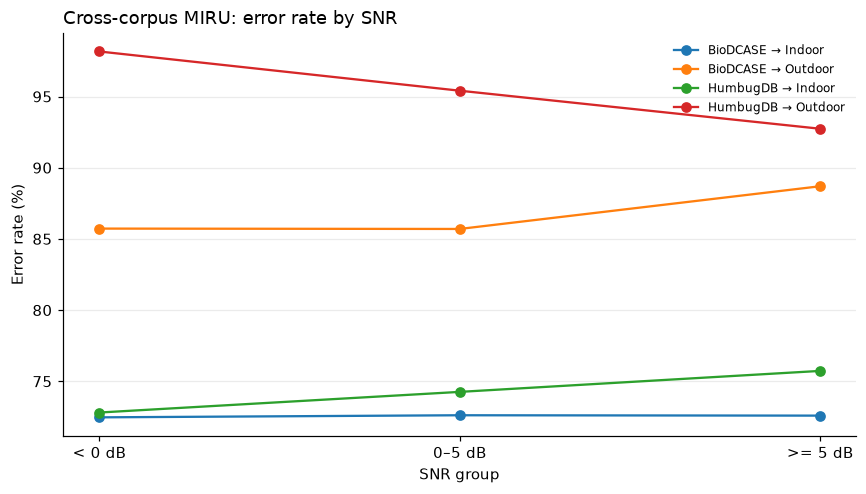

In [27]:
snr=mos[mos[SNR_COL].notna()].copy()
snr["SNR group"]=pd.cut(snr[SNR_COL],[-np.inf,0,5,np.inf],labels=["< 0 dB","0–5 dB",">= 5 dB"],right=False)

g=snr.groupby(["ModelKey","Seed","Setting","SNR group"],observed=True).Error.mean().mul(100).reset_index()
snr_result=g.groupby(["ModelKey","Setting","SNR group"],observed=True).Error.mean().reset_index(name="Error %")

display(snr_result[snr_result.ModelKey==TARGET_MODEL].round(2))
snr_result.to_csv(OUT_DIR/"snr_error_miru_cross.csv",index=False)

x=snr_result[snr_result.ModelKey==TARGET_MODEL]
fig,ax=plt.subplots(figsize=(8,4.6))

for st,d in x.groupby("Setting"):
    ax.plot(d["SNR group"].astype(str),d["Error %"],marker="o",label=short_setting(st))

ax.set_xlabel("SNR group")
ax.set_ylabel("Error rate (%)")
ax.set_title("Cross-corpus MIRU: error rate by SNR",loc="left")
ax.legend(frameon=False,fontsize=8)
ax.grid(axis="y",alpha=.25)
plt.tight_layout(); save("fig_err_by_snr_setting"); plt.show()

In [5]:
p=x.pivot(index="Setting",columns="SNR group",values="Error %")
if "< 0 dB" in p.columns and ">= 5 dB" in p.columns: p["Low - high SNR (pp)"]=p["< 0 dB"]-p[">= 5 dB"]
p.index=[short_setting(i) for i in p.index]; display(p.round(2)); p.to_csv(OUT_DIR/"takeaway_snr_mosbeatnet.csv")


SNR group,< 0 dB,0–5 dB,>= 5 dB,Low - high SNR (pp)
BioDCASE → Indoor,72.47,72.62,72.59,-0.12
BioDCASE → Outdoor,85.72,85.70,88.70,-2.97
HumbugDB → Indoor,72.81,74.26,75.73,-2.92
HumbugDB → Outdoor,98.16,95.41,92.74,5.43


### 2.2 Mosquito RMS

`mosquito_rms` is stored in the original simulation metadata rather than in `segment_predictions.csv`. For each true mosquito segment, the overlapping mosquito event with the largest overlap is used, and the final output gain is applied before conversion to dBFS.

**Takeaway to read:** whether errors concentrate at low/high mosquito energy, and whether the pattern changes across the four cross-corpus settings.

In [6]:
meta_files=sorted(META_DIR.glob("metadata_test_*.csv")); meta=pd.concat([pd.read_csv(p,low_memory=False) for p in meta_files],ignore_index=True,sort=False)
meta["file_key"]=meta.file_name.astype(str).map(lambda x:Path(x).name)
for col in ["start_time","end_time","mosquito_rms","output_gain"]: meta[col]=pd.to_numeric(meta[col],errors="coerce")
events=meta[meta.event_type.astype(str).str.lower().eq("mosquito")][["file_key","start_time","end_time","mosquito_rms","output_gain"]].rename(columns={"start_time":"event_start","end_time":"event_end"})
seg=mos[["Experiment","Test Set","file_key","segment_index","start_time","end_time"]].drop_duplicates(); cand=seg.merge(events,on="file_key",how="left")
cand["overlap"]=(np.minimum(cand.end_time,cand.event_end)-np.maximum(cand.start_time,cand.event_start)).clip(lower=0)
best=cand[cand.overlap>0].sort_values("overlap").drop_duplicates(["Experiment","Test Set","file_key","segment_index"],keep="last")
best["mosquito_rms_dbfs"]=20*np.log10((best.mosquito_rms*best.output_gain).clip(lower=1e-12))
mos=mos.merge(best[["Experiment","Test Set","file_key","segment_index","mosquito_rms_dbfs"]],on=["Experiment","Test Set","file_key","segment_index"],how="left"); ac=ac.merge(best[["Experiment","Test Set","file_key","segment_index","mosquito_rms_dbfs"]],on=["Experiment","Test Set","file_key","segment_index"],how="left")
print("RMS mapped:",mos.mosquito_rms_dbfs.notna().sum(),"/",len(mos))


RMS mapped: 492610 / 492610


,ModelKey,Setting,RMS group,Error %,SD
20,mosbeatnet_v2,BioDCASE → MIRU-indoor,Q1 low,73.42,NaN
21,mosbeatnet_v2,BioDCASE → MIRU-indoor,Q2,72.44,NaN
22,mosbeatnet_v2,BioDCASE → MIRU-indoor,Q3,72.87,NaN
23,mosbeatnet_v2,BioDCASE → MIRU-indoor,Q4,71.60,NaN
24,mosbeatnet_v2,BioDCASE → MIRU-indoor,Q5 high,72.41,NaN
25,mosbeatnet_v2,BioDCASE → MIRU-outdoor,Q1 low,86.04,NaN
26,mosbeatnet_v2,BioDCASE → MIRU-outdoor,Q2,85.79,NaN
27,mosbeatnet_v2,BioDCASE → MIRU-outdoor,Q3,85.33,NaN
28,mosbeatnet_v2,BioDCASE → MIRU-outdoor,Q4,87.47,NaN
29,mosbeatnet_v2,BioDCASE → MIRU-outdoor,Q5 high,88.79,NaN


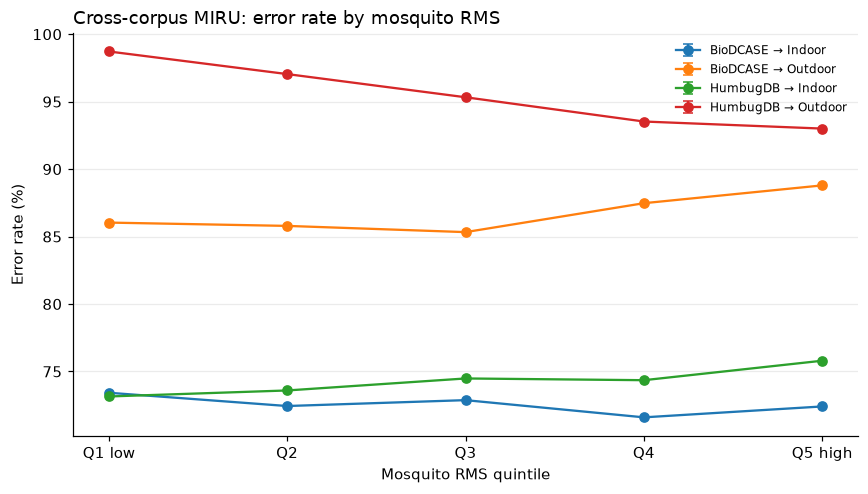

In [16]:
rms=mos[mos.mosquito_rms_dbfs.notna()].copy(); rms["RMS group"]=pd.qcut(rms.mosquito_rms_dbfs,5,labels=["Q1 low","Q2","Q3","Q4","Q5 high"],duplicates="drop")
g=rms.groupby(["ModelKey","Seed","Setting","RMS group"],observed=True).Error.mean().mul(100).reset_index(); rms_result=g.groupby(["ModelKey","Setting","RMS group"],observed=True).Error.agg(["mean","std"]).reset_index().rename(columns={"mean":"Error %","std":"SD"})
display(rms_result[rms_result.ModelKey==TARGET_MODEL].round(2)); rms_result.to_csv(OUT_DIR/"mosquito_rms_error_miru_cross.csv",index=False)

x=rms_result[rms_result.ModelKey==TARGET_MODEL]; fig,ax=plt.subplots(figsize=(8,4.6))
for st,d in x.groupby("Setting"): ax.errorbar(d["RMS group"].astype(str),d["Error %"],yerr=d.SD,marker="o",capsize=3,label=short_setting(st))
ax.set_xlabel("Mosquito RMS quintile"); ax.set_ylabel("Error rate (%)"); ax.set_title("Cross-corpus MIRU: error rate by mosquito RMS",loc="left"); ax.legend(frameon=False,fontsize=8); ax.grid(axis="y",alpha=.25); plt.tight_layout(); save("fig_err_by_rms_setting"); plt.show()


In [8]:
p=x.pivot(index="Setting",columns="RMS group",values="Error %"); worst=p.idxmax(axis=1).rename("Worst RMS group"); take_rms=pd.concat([p,worst],axis=1); take_rms.index=[short_setting(i) for i in take_rms.index]
display(take_rms.round(2)); take_rms.to_csv(OUT_DIR/"takeaway_rms_mosbeatnet.csv")


,Q1 low,Q2,Q3,Q4,Q5 high,Worst RMS group
BioDCASE → Indoor,73.42,72.44,72.87,71.60,72.41,Q1 low
BioDCASE → Outdoor,86.04,85.79,85.33,87.47,88.79,Q5 high
HumbugDB → Indoor,73.15,73.59,74.48,74.35,75.80,Q5 high
HumbugDB → Outdoor,98.72,97.04,95.33,93.53,93.00,Q1 low


### 2.3 Species × SNR / RMS

These heatmaps are **pooled across the four cross-corpus MIRU settings** for MosBeatNet only. They are used to see whether an acoustic trend is concentrated in particular species, not to compare domains.

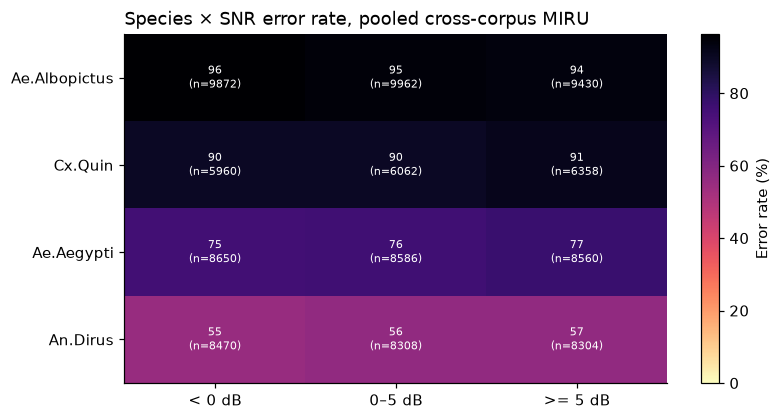

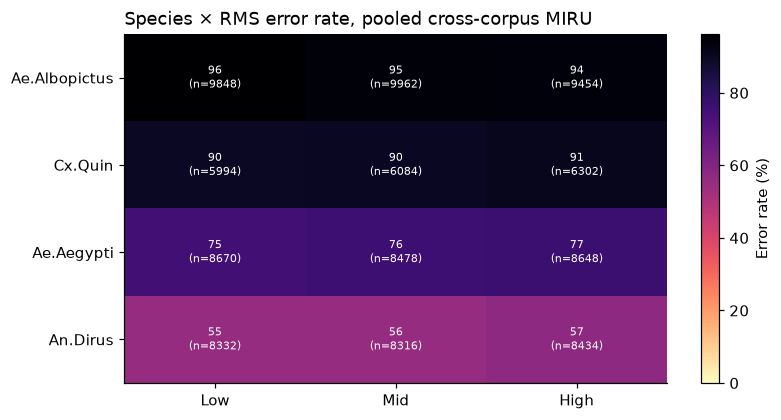

In [9]:
def group_heatmap(df,row,group,title,fname,min_n=20):
    rate=df.groupby([row,group],observed=True).Error.mean().mul(100).unstack(); n=df.groupby([row,group],observed=True).size().unstack(); rate=rate.loc[rate.mean(axis=1).sort_values(ascending=False).index]; n=n.reindex(rate.index); m=rate.where(n>=min_n)
    if m.isna().all().all(): print("No cell reaches min_n =",min_n); return
    vmax=np.nanmax(m.values); fig,ax=plt.subplots(figsize=(1.5*m.shape[1]+3,.48*m.shape[0]+2)); im=ax.imshow(m.values,cmap="magma_r",vmin=0,vmax=vmax,aspect="auto")
    ax.set_xticks(range(m.shape[1]),[str(v) for v in m.columns]); ax.set_yticks(range(m.shape[0]),m.index)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v=m.values[i,j]
            if not np.isnan(v): ax.text(j,i,f"{v:.0f}\n(n={int(n.values[i,j])})",ha="center",va="center",fontsize=7.5,color="white" if v>vmax/2 else "black")
    ax.set_title(title,loc="left"); fig.colorbar(im,ax=ax,label="Error rate (%)"); plt.tight_layout(); save(fname); plt.show()

x=mos[(mos.ModelKey==TARGET_MODEL) & mos[SNR_COL].notna()].copy(); x["SNR group"]=pd.cut(x[SNR_COL],[-np.inf,0,5,np.inf],labels=["< 0 dB","0–5 dB",">= 5 dB"],right=False)
group_heatmap(x,"true_label","SNR group","Species × SNR error rate, pooled cross-corpus MIRU","fig_heat_species_snr")

x=mos[(mos.ModelKey==TARGET_MODEL) & mos.mosquito_rms_dbfs.notna()].copy(); x["RMS group"]=pd.qcut(x.mosquito_rms_dbfs,3,labels=["Low","Mid","High"],duplicates="drop")
group_heatmap(x,"true_label","RMS group","Species × RMS error rate, pooled cross-corpus MIRU","fig_heat_species_rms")


### 2.4 Correct vs wrong acoustic conditions

This is a **pooled descriptive view across the four cross-corpus MIRU settings** for MosBeatNet. The table is also shown by setting so the pooled result is not mistaken for a single domain.

,Setting,Result,N,SNR_median,RMS_median
0,BioDCASE → Indoor,Correct,9029,2.55,-27.79
1,BioDCASE → Indoor,Wrong,23874,2.44,-27.99
2,BioDCASE → Outdoor,Correct,2177,1.93,-28.16
3,BioDCASE → Outdoor,Wrong,14181,2.55,-27.62
4,HumbugDB → Indoor,Correct,8468,2.15,-28.19
5,HumbugDB → Indoor,Wrong,24435,2.60,-27.86
6,HumbugDB → Outdoor,Correct,743,5.26,-24.91
7,HumbugDB → Outdoor,Wrong,15615,2.32,-27.85


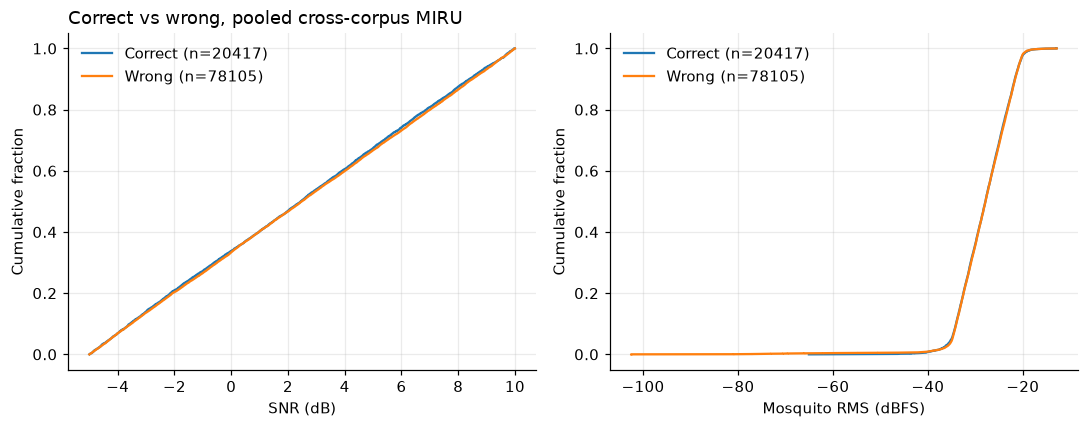

In [10]:
cw=mos[(mos.ModelKey==TARGET_MODEL) & mos[SNR_COL].notna() & mos.mosquito_rms_dbfs.notna()].copy(); cw["Result"]=np.where(cw.correct,"Correct","Wrong")
cw_summary=cw.groupby(["Setting","Result"]).agg(N=("correct","size"),SNR_median=(SNR_COL,"median"),RMS_median=("mosquito_rms_dbfs","median")).reset_index(); cw_summary["Setting"]=cw_summary.Setting.map(short_setting)
display(cw_summary.round(2)); cw_summary.to_csv(OUT_DIR/"correct_wrong_acoustic_summary.csv",index=False)

fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,(col,lab) in zip(axes,[(SNR_COL,"SNR (dB)"),("mosquito_rms_dbfs","Mosquito RMS (dBFS)")]):
    for res in ["Correct","Wrong"]:
        v=np.sort(cw.loc[cw.Result==res,col].dropna().values)
        if len(v): ax.plot(v,np.arange(1,len(v)+1)/len(v),label=f"{res} (n={len(v)})")
    ax.set_xlabel(lab); ax.set_ylabel("Cumulative fraction"); ax.grid(alpha=.25); ax.legend(frameon=False)
axes[0].set_title("Correct vs wrong, pooled cross-corpus MIRU",loc="left"); plt.tight_layout(); save("fig_ecdf_correct_wrong"); plt.show()


### 2.5 Acoustic conditions of common confusion pairs

Confusion pairs are summarized **per cross-corpus setting** first. This avoids hiding a setting-specific confusion pattern inside one pooled ranking.

,Setting,Pair,Count,Mean_SNR,Mean_RMS,Rank
5,BioDCASE → MIRU-indoor,Ae.Albopictus → An.Dirus,6488,2.72,-27.79,1.0
1,BioDCASE → MIRU-indoor,Ae.Aegypti → An.Dirus,5715,2.72,-27.68,2.0
14,BioDCASE → MIRU-indoor,Cx.Quin → An.Dirus,4988,2.68,-27.77,3.0
4,BioDCASE → MIRU-indoor,Ae.Albopictus → Ae.Aegypti,1215,3.34,-26.86,4.0
6,BioDCASE → MIRU-indoor,Ae.Albopictus → Cx.Quin,977,0.70,-30.13,5.0
20,BioDCASE → MIRU-outdoor,Ae.Albopictus → Ae.Aegypti,2755,1.97,-28.07,1.0
23,BioDCASE → MIRU-outdoor,Ae.Albopictus → Noise,2071,2.76,-27.48,2.0
19,BioDCASE → MIRU-outdoor,Ae.Aegypti → Noise,1989,2.34,-28.07,3.0
27,BioDCASE → MIRU-outdoor,An.Dirus → Noise,1652,2.67,-27.48,4.0
31,BioDCASE → MIRU-outdoor,Cx.Quin → Noise,1371,2.82,-27.58,5.0


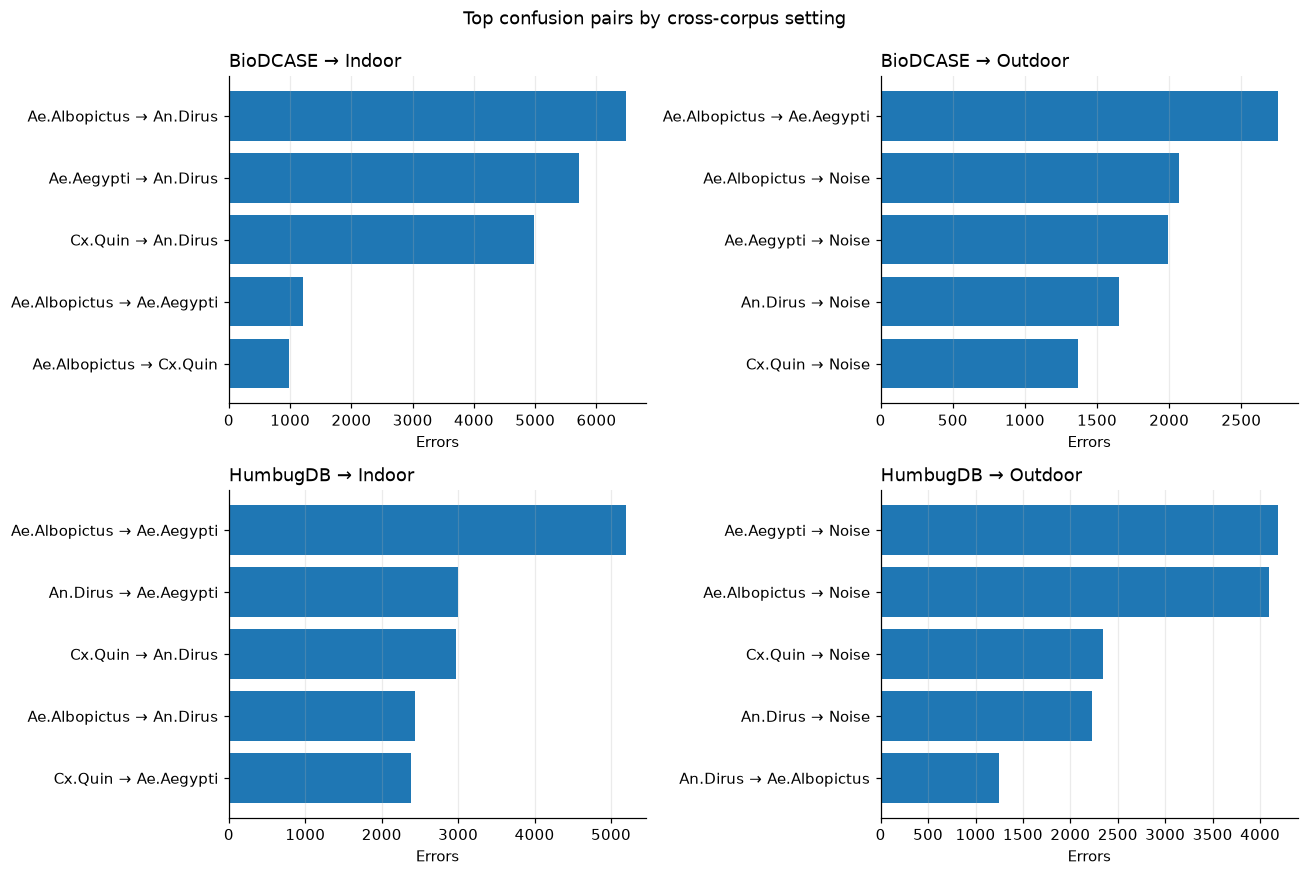

In [11]:
conf=mos[(mos.ModelKey==TARGET_MODEL) & ~mos.correct].copy(); conf["Pair"]=conf.true_label.astype(str)+" → "+conf.predicted_label.astype(str)
pair_acoustic=conf.groupby(["Setting","Pair"]).agg(Count=("Pair","size"),Mean_SNR=(SNR_COL,"mean"),Mean_RMS=("mosquito_rms_dbfs","mean")).reset_index(); pair_acoustic["Rank"]=pair_acoustic.groupby("Setting").Count.rank(method="first",ascending=False)
top_pairs=pair_acoustic[pair_acoustic.Rank<=5].sort_values(["Setting","Rank"]); display(top_pairs.round(2)); pair_acoustic.to_csv(OUT_DIR/"confusion_pair_acoustics_miru_cross.csv",index=False)

settings=sorted(top_pairs.Setting.unique()); fig,axes=plt.subplots(2,2,figsize=(12,8)); axes=axes.ravel()
for ax,st in zip(axes,settings):
    d=top_pairs[top_pairs.Setting==st].sort_values("Count"); ax.barh(d.Pair,d.Count); ax.set_title(short_setting(st),loc="left"); ax.set_xlabel("Errors"); ax.grid(axis="x",alpha=.25)
for ax in axes[len(settings):]: ax.axis("off")
fig.suptitle("Top confusion pairs by cross-corpus setting",y=.99); plt.tight_layout(); save("fig_confusion_pairs_cross_setting"); plt.show()


## 3. Background false positives (`sp5`)

**Scope:** the same four BioDCASE/HumbugDB → MIRU settings, but now only true Noise segments.  
**Question:** which background sub-environments are most likely to be predicted as mosquito, and is that pattern specific to the training/test setting?

In [12]:
env_col="metadata_simulation_environment" if "metadata_simulation_environment" in ac.columns else "simulation_environment"; sub_col="metadata_subenv" if "metadata_subenv" in ac.columns else "subenv"
bg=ac[(ac.ModelKey==TARGET_MODEL) & ac.true_label.map(is_noise)].copy(); bg["False positive"]=~bg.predicted_label.map(is_noise); bg[sub_col]=bg[sub_col].fillna("unknown")
bg_result=bg.groupby(["Setting",sub_col],dropna=False).agg(N=("False positive","size"),FP_pct=("False positive","mean")).reset_index(); bg_result.FP_pct*=100
bg_result["Setting short"]=bg_result.Setting.map(short_setting); display(bg_result.sort_values(["Setting","FP_pct"],ascending=[True,False]).round(2)); bg_result.to_csv(OUT_DIR/"background_error_miru_cross.csv",index=False)


,Setting,metadata_subenv,N,FP_pct,Setting short
2,BioDCASE → MIRU-indoor,Drippingwater,7163,1.70,BioDCASE → Indoor
0,BioDCASE → MIRU-indoor,Centre,5657,1.41,BioDCASE → Indoor
7,BioDCASE → MIRU-indoor,riverside,7152,1.40,BioDCASE → Indoor
3,BioDCASE → MIRU-indoor,Park,5765,1.04,BioDCASE → Indoor
6,BioDCASE → MIRU-indoor,rain,7145,0.50,BioDCASE → Indoor
5,BioDCASE → MIRU-indoor,bird,7159,0.39,BioDCASE → Indoor
4,BioDCASE → MIRU-indoor,aircon,5663,0.32,BioDCASE → Indoor
1,BioDCASE → MIRU-indoor,Doves and other birds,5658,0.30,BioDCASE → Indoor
8,BioDCASE → MIRU-indoor,waterrun,5735,0.12,BioDCASE → Indoor
9,BioDCASE → MIRU-outdoor,gaussian,28642,37.93,BioDCASE → Outdoor


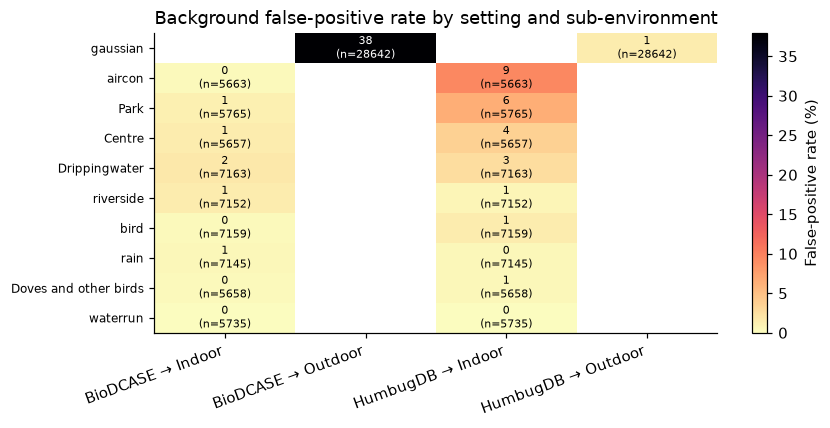

,Setting short,metadata_subenv,N,FP_pct
9,BioDCASE → Outdoor,gaussian,28642,37.93
14,HumbugDB → Indoor,aircon,5663,9.43
2,BioDCASE → Indoor,Drippingwater,7163,1.70
19,HumbugDB → Outdoor,gaussian,28642,1.35


In [25]:
rate=bg_result.pivot(index=sub_col,columns="Setting short",values="FP_pct")
n=bg_result.pivot(index=sub_col,columns="Setting short",values="N")

rate=rate.loc[rate.mean(axis=1).sort_values(ascending=False).index]
n=n.reindex(index=rate.index,columns=rate.columns)
m=rate.where(n>=50)

fig,ax=plt.subplots(figsize=(8,max(4,.38*len(m))))
vmax=np.nanmax(m.values) if m.notna().any().any() else 1
im=ax.imshow(m.values,cmap="magma_r",vmin=0,vmax=vmax,aspect="auto")

ax.set_xticks(range(m.shape[1]),m.columns,rotation=20,ha="right")
ax.set_yticks(range(m.shape[0]),m.index,fontsize=8)

for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v=m.iloc[i,j]; count=n.iloc[i,j]
        if pd.notna(v):
            ax.text(j,i,f"{v:.0f}\n(n={int(count)})",ha="center",va="center",fontsize=7,
                    color="white" if v>vmax/2 else "black")

ax.set_title("Background false-positive rate by setting and sub-environment",loc="left")
fig.colorbar(im,ax=ax,label="False-positive rate (%)")
plt.tight_layout(); save("fig_background_fp_heatmap"); plt.show()

top_bg=bg_result.loc[bg_result.groupby("Setting").FP_pct.idxmax(),
                     ["Setting short",sub_col,"N","FP_pct"]].sort_values("FP_pct",ascending=False)
display(top_bg.round(2))
top_bg.to_csv(OUT_DIR/"takeaway_background_fp.csv",index=False)

## 4. Species+sex confusion (`sx9`, MIRU only)

This section uses MosBeatNet only and keeps six MIRU settings visible:

- **Same environment:** Indoor → Indoor, Outdoor → Outdoor
- **Environment transfer:** Indoor → Outdoor, Outdoor → Indoor
- **Mixed training:** Mixed → Indoor, Mixed → Outdoor

The confusion figures are shown per setting rather than silently pooling all six experiments.

In [18]:
sx=pred[(pred.Task=="species_sex") & (pred.ModelKey==TARGET_MODEL) & pred.Test.isin(["MIRU-indoor","MIRU-outdoor"]) & pred.Train.isin(["MIRU-indoor","MIRU-outdoor","MIRU indoor+outdoor"])].copy(); sx["Setting"]=sx.Train+" → "+sx.Test; sx["Setting short"]=sx.Setting.map(short_setting)
sx["Setting type"]=np.select([sx.Train==sx.Test,sx.Train.eq("MIRU indoor+outdoor")],["Same environment","Mixed training"],default="Environment transfer")

def split_label(x):
    x=str(x)
    if is_noise(x): return "Noise",None
    if "_" in x:
        sp,sex=x.rsplit("_",1)
        if sex in {"F","M"}: return sp,sex
    return x,None

def error_type(r):
    if r.true_label==r.predicted_label: return "Correct"
    a,sa=split_label(r.true_label); b,sb=split_label(r.predicted_label)
    if a=="Noise": return "Noise → Mosquito"
    if b=="Noise": return "Mosquito → Noise"
    if a!=b: return "Different species"
    if sa and sb and sa!=sb: return "Same species, wrong sex"
    return "Other"

sx["Error type"]=sx.apply(error_type,axis=1); display(sx[["Setting short","Setting type"]].drop_duplicates().sort_values(["Setting type","Setting short"]))


,Setting short,Setting type
1895000,Indoor → Outdoor,Environment transfer
4210000,Outdoor → Indoor,Environment transfer
11485000,Mixed → Indoor,Mixed training
11595000,Mixed → Outdoor,Mixed training
1785000,Indoor → Indoor,Same environment
4320000,Outdoor → Outdoor,Same environment


### 4.1 What kind of mistakes does the model make?

Each bar sums to 100% of the errors in that setting. This separates wrong-sex errors from different-species errors and mosquito↔noise errors.

,Setting short,Setting type,Error type,Count,Share %
0,Indoor → Indoor,Same environment,Different species,7373,74.8
1,Indoor → Indoor,Same environment,Mosquito → Noise,979,9.9
2,Indoor → Indoor,Same environment,Noise → Mosquito,283,2.9
3,Indoor → Indoor,Same environment,"Same species, wrong sex",1223,12.4
4,Indoor → Outdoor,Environment transfer,Different species,14,0.1
5,Indoor → Outdoor,Environment transfer,Mosquito → Noise,16343,99.4
6,Indoor → Outdoor,Environment transfer,Noise → Mosquito,76,0.5
7,Indoor → Outdoor,Environment transfer,"Same species, wrong sex",1,0.0
8,Mixed → Indoor,Mixed training,Different species,7433,72.5
9,Mixed → Indoor,Mixed training,Mosquito → Noise,1137,11.1


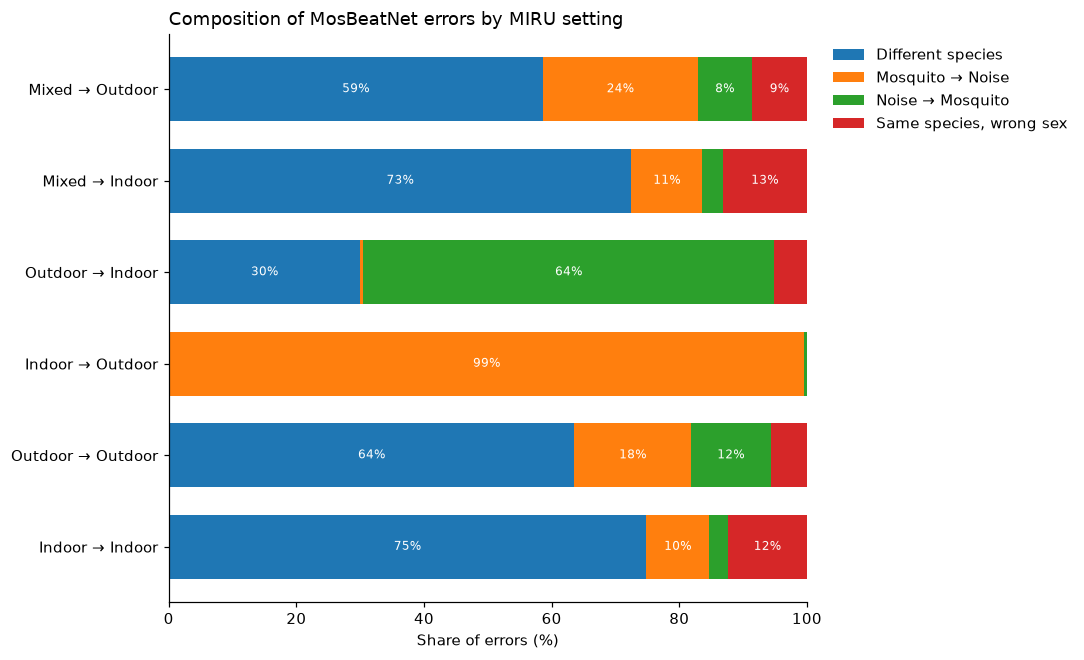

In [19]:
err=sx[sx["Error type"]!="Correct"].copy(); conf_types=err.groupby(["Setting short","Setting type","Error type"]).size().rename("Count").reset_index(); conf_types["Share %"]=conf_types.Count/conf_types.groupby("Setting short").Count.transform("sum")*100
display(conf_types.round(1)); conf_types.to_csv(OUT_DIR/"confusion_types_sx9_miru.csv",index=False)

sh=conf_types.pivot(index="Setting short",columns="Error type",values="Share %").fillna(0); ct=conf_types.pivot(index="Setting short",columns="Error type",values="Count").fillna(0)
order=["Indoor → Indoor","Outdoor → Outdoor","Indoor → Outdoor","Outdoor → Indoor","Mixed → Indoor","Mixed → Outdoor"]; sh=sh.reindex([x for x in order if x in sh.index]); ct=ct.reindex(sh.index)
ax=sh.plot.barh(stacked=True,figsize=(10,.65*len(sh)+2.2),width=.7)
for i,s in enumerate(sh.index):
    left=0
    for col in sh.columns:
        w=sh.loc[s,col]
        if w>=7: ax.text(left+w/2,i,f"{w:.0f}%",ha="center",va="center",fontsize=8,color="white")
        left+=w
ax.set_xlabel("Share of errors (%)"); ax.set_ylabel(""); ax.set_xlim(0,100); ax.set_title("Composition of MosBeatNet errors by MIRU setting",loc="left"); ax.legend(title="",bbox_to_anchor=(1.02,1),loc="upper left",frameon=False); plt.tight_layout(); save("fig_error_types_stacked"); plt.show()


### 4.2 Top confusion pairs by setting

The ranking is kept separate for each MIRU setting so a frequent pair in one experiment does not dominate a pooled list.

In [21]:
pairs=err.groupby(["Setting short","true_label","predicted_label"]).size().rename("Count").reset_index().sort_values(["Setting short","Count"],ascending=[True,False]); top_pairs=pairs.groupby("Setting short").head(5).copy(); top_pairs["Pair"]=top_pairs.true_label+" → "+top_pairs.predicted_label
display(top_pairs[["Setting short","Pair","Count"]]); 
# pairs.to_csv(OUT_DIR/"confusion_pairs_sx9_miru.csv",index=False)


,Setting short,Pair,Count
41,Indoor → Indoor,An.Dirus_M → Ae.Aegypti_M,799
12,Indoor → Indoor,Ae.Aegypti_M → An.Dirus_M,601
19,Indoor → Indoor,Ae.Albopictus_F → An.Dirus_F,413
62,Indoor → Indoor,Cx.Quin_M → Cx.Quin_F,403
25,Indoor → Indoor,Ae.Albopictus_M → Ae.Aegypti_M,400
73,Indoor → Outdoor,Ae.Aegypti_F → Noise,4172
79,Indoor → Outdoor,Ae.Albopictus_F → Noise,3958
84,Indoor → Outdoor,Cx.Quin_M → Noise,2820
83,Indoor → Outdoor,An.Dirus_M → Noise,2323
81,Indoor → Outdoor,An.Dirus_F → Noise,1184


### 4.3 Normalized confusion matrix per setting

Rows are normalized by the true class. Values below 0.05 are not annotated to keep the matrix readable.

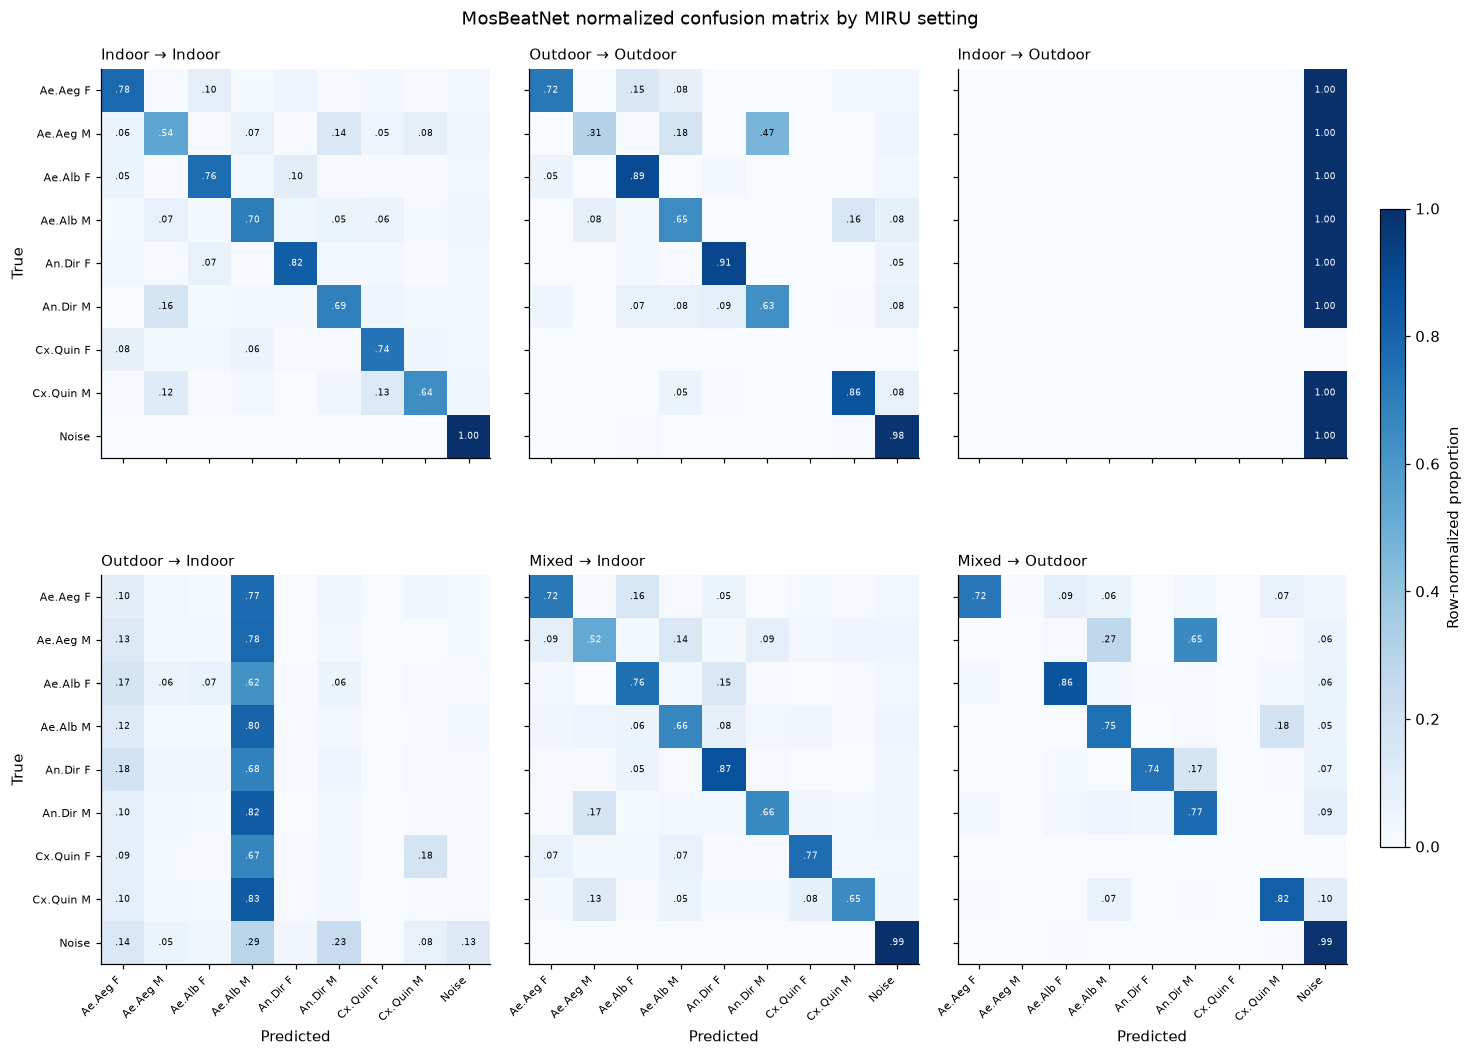

In [26]:
labels=sorted(set(sx.true_label.astype(str))|set(sx.predicted_label.astype(str)))
class_names=[x.replace("Ae.Aegypti","Ae.Aeg").replace("Ae.Albopictus","Ae.Alb").replace("An.Dirus","An.Dir").replace("_F"," F").replace("_M"," M") for x in labels]
settings=[x for x in order if x in sx["Setting short"].unique()]

fig,axes=plt.subplots(2,3,figsize=(15,10),sharex=True,sharey=True)
axes=axes.ravel()

for ax,st in zip(axes,settings):
    d=sx[sx["Setting short"]==st]
    cm=confusion_matrix(d.true_label,d.predicted_label,labels=labels,normalize="true")
    im=ax.imshow(cm,vmin=0,vmax=1,cmap="Blues")
    ax.set_xticks(range(len(labels)),class_names,rotation=45,ha="right",fontsize=7)
    ax.set_yticks(range(len(labels)),class_names,fontsize=7)
    ax.set_title(st,loc="left",fontsize=10)

    for i in range(len(labels)):
        for j in range(len(labels)):
            v=cm[i,j]
            if v>=.05:
                ax.text(j,i,f"{v:.2f}".lstrip("0"),ha="center",va="center",fontsize=6,
                        color="white" if v>.5 else "black")

for ax in axes[len(settings):]:
    ax.axis("off")

for ax in axes[-3:]:
    ax.set_xlabel("Predicted")
for ax in axes[::3]:
    ax.set_ylabel("True")

fig.suptitle("MosBeatNet normalized confusion matrix by MIRU setting",y=.98)
plt.subplots_adjust(wspace=.10,hspace=.28,right=.88,top=.93)

cax=fig.add_axes([0.90,0.22,0.015,0.58])   # left, bottom, width, height
fig.colorbar(im,cax=cax,label="Row-normalized proportion")

plt.show()

### 4.4 How much accuracy is lost when sex must also be correct?

For true mosquito segments, compare species-only accuracy with full species+sex accuracy. The second figure shows sex accuracy **conditional on the species already being correct**.

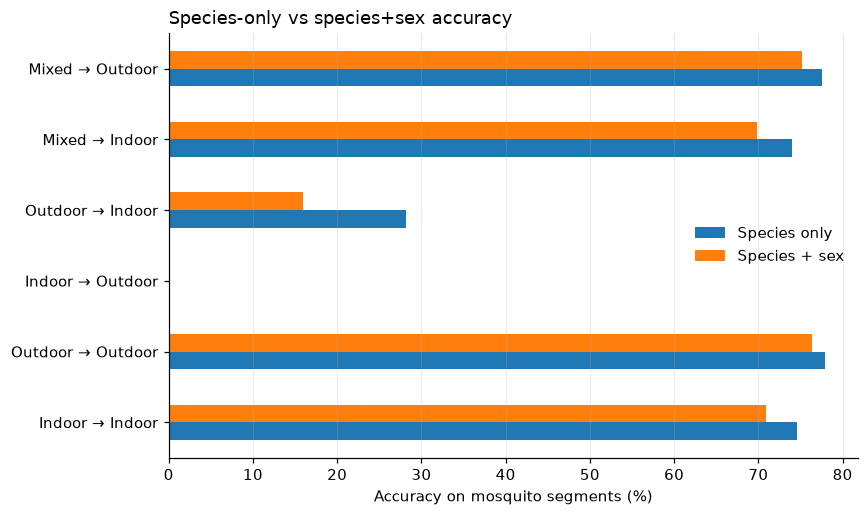

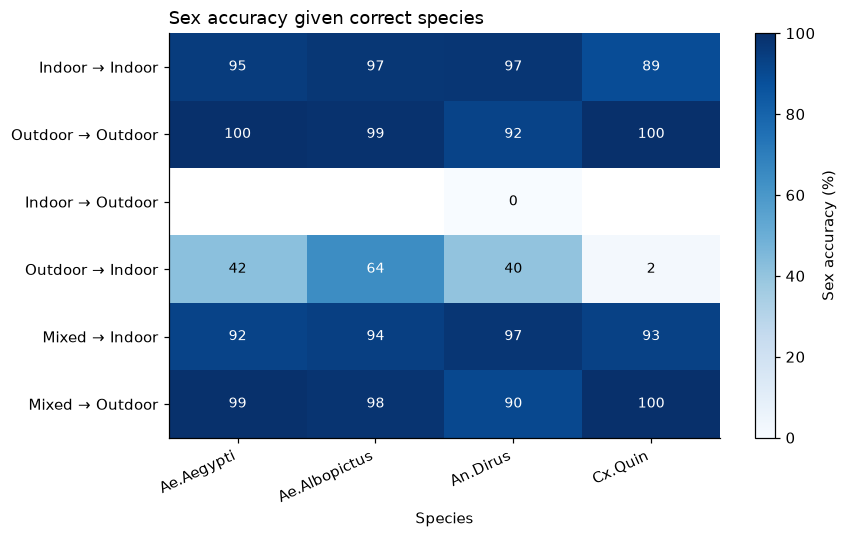

In [23]:
sp=sx.copy()
for side in ["true","predicted"]:
    parts=sp[f"{side}_label"].map(split_label); sp[f"{side}_sp"]=parts.str[0]; sp[f"{side}_sex"]=parts.str[1]
mos_sx=sp[sp.true_sp!="Noise"].copy(); acc=pd.DataFrame({"Species only":mos_sx.groupby("Setting short").apply(lambda d:(d.true_sp==d.predicted_sp).mean()*100),"Species + sex":mos_sx.groupby("Setting short").apply(lambda d:d.correct.mean()*100)}).reindex(settings)
ax=acc.plot.barh(figsize=(8,4.8)); ax.set_xlabel("Accuracy on mosquito segments (%)"); ax.set_ylabel(""); ax.set_title("Species-only vs species+sex accuracy",loc="left"); ax.legend(frameon=False); ax.grid(axis="x",alpha=.25); plt.tight_layout(); save("fig_species_vs_sex_accuracy"); plt.show()

same=mos_sx[mos_sx.true_sp==mos_sx.predicted_sp].copy(); same["sex_ok"]=same.true_sex==same.predicted_sex; sex_acc=same.groupby(["Setting short","true_sp"]).sex_ok.mean().mul(100).unstack().reindex(settings)
fig,ax=plt.subplots(figsize=(8,5)); im=ax.imshow(sex_acc,aspect="auto",vmin=0,vmax=100,cmap="Blues"); ax.set_xticks(range(len(sex_acc.columns)),sex_acc.columns,rotation=25,ha="right"); ax.set_yticks(range(len(sex_acc.index)),sex_acc.index)
for i in range(sex_acc.shape[0]):
    for j in range(sex_acc.shape[1]):
        v=sex_acc.iloc[i,j]
        if pd.notna(v): ax.text(j,i,f"{v:.0f}",ha="center",va="center",color="white" if v>60 else "black",fontsize=9)
ax.set_xlabel("Species"); ax.set_ylabel(""); ax.set_title("Sex accuracy given correct species",loc="left"); fig.colorbar(im,ax=ax,label="Sex accuracy (%)"); plt.tight_layout(); save("fig_sex_accuracy_species"); plt.show()


In [24]:
acc["Sex requirement cost (pp)"]=acc["Species only"]-acc["Species + sex"]; display(acc.round(2)); acc.to_csv(OUT_DIR/"takeaway_species_vs_sex_accuracy.csv")
main_error=conf_types.loc[conf_types.groupby("Setting short")["Share %"].idxmax(),["Setting short","Error type","Share %","Count"]].reindex(columns=["Setting short","Error type","Share %","Count"]); display(main_error.sort_values("Setting short").round(2)); main_error.to_csv(OUT_DIR/"takeaway_main_error_type.csv",index=False)


,Species only,Species + sex,Sex requirement cost (pp)
Setting short,,,
Indoor → Indoor,74.62,70.90,3.72
Outdoor → Outdoor,77.93,76.40,1.53
Indoor → Outdoor,0.01,0.00,0.01
Outdoor → Indoor,28.22,15.99,12.23
Mixed → Indoor,73.95,69.84,4.12
Mixed → Outdoor,77.50,75.15,2.35


,Setting short,Error type,Share %,Count
0,Indoor → Indoor,Different species,74.79,7373
5,Indoor → Outdoor,Mosquito → Noise,99.45,16343
8,Mixed → Indoor,Different species,72.50,7433
12,Mixed → Outdoor,Different species,58.61,2603
18,Outdoor → Indoor,Noise → Mosquito,64.29,49759
20,Outdoor → Outdoor,Different species,63.57,2804


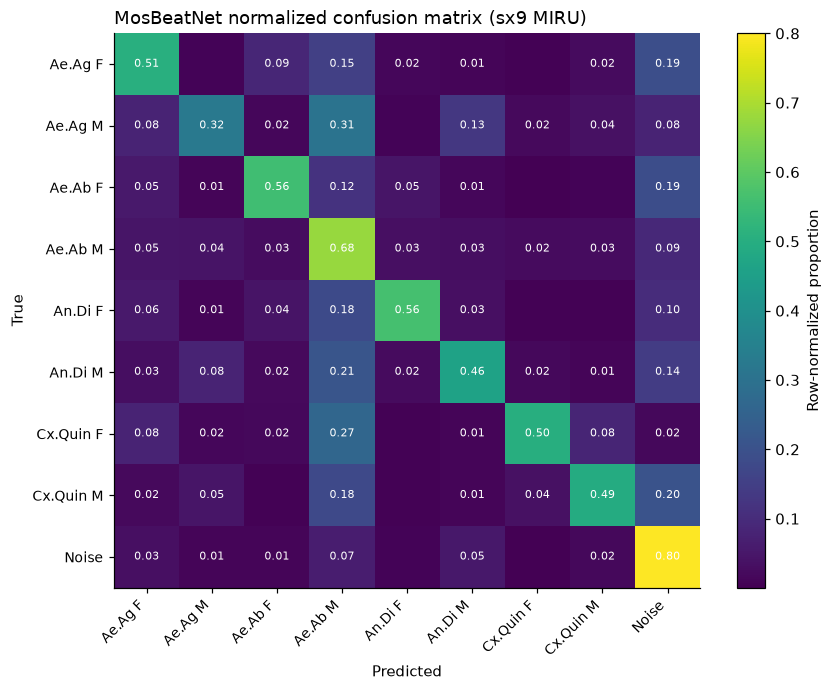

In [29]:

# labels = sorted(set(sx["true_label"].astype(str)) | set(sx["predicted_label"].astype(str))); cm = confusion_matrix(sx["true_label"],sx["predicted_label"],labels=labels,normalize="true")
# fig,ax = plt.subplots(figsize=(8,7)); im = ax.imshow(cm,aspect="auto"); fig.colorbar(im,ax=ax,label="Row-normalized proportion"); ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels))); ax.set_xticklabels(labels,rotation=45,ha="right"); ax.set_yticklabels(labels); ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("MosBeatNet normalized confusion matrix (sx9 MIRU)",loc="left"); plt.tight_layout(); plt.show()


labels = sorted(set(sx["true_label"].astype(str)) | set(sx["predicted_label"].astype(str)))
cm = confusion_matrix(sx["true_label"], sx["predicted_label"], labels=labels, normalize="true")

short_labels = [
    x.replace("Ae.Aegypti", "Ae.Ag")
     .replace("Ae.Albopictus", "Ae.Ab")
     .replace("An.Dirus", "An.Di")
     .replace("_F", " F")
     .replace("_M", " M")
    for x in labels
]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm,aspect="auto")
fig.colorbar(im, ax=ax, label="Row-normalized proportion")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm[i, j]
        if v >= 0.01:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white")

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("MosBeatNet normalized confusion matrix (sx9 MIRU)", loc="left")

plt.subplots_adjust(left=.18, bottom=.20, right=.92, top=.92)
plt.show()

## 5. Background false positives

,metadata_simulation_environment,metadata_subenv,N,FP_pct
4,gaussian,gaussian,57284,19.64
8,urban,aircon,11326,4.87
7,urban,Park,11530,3.73
5,urban,Centre,11314,2.54
0,forest,Drippingwater,14326,2.18
3,forest,riverside,14304,1.05
1,forest,bird,14318,0.91
2,forest,rain,14290,0.49
6,urban,Doves and other birds,11316,0.42
9,urban,waterrun,11470,0.12


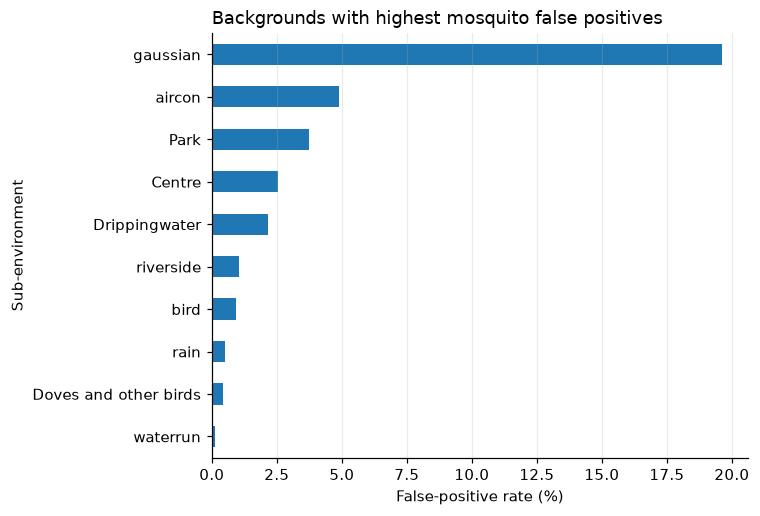

In [32]:
env_col = "metadata_simulation_environment" if "metadata_simulation_environment" in ac.columns else "simulation_environment"; sub_col = "metadata_subenv" if "metadata_subenv" in ac.columns else "subenv"
bg = ac[(ac["ModelKey"]==TARGET_MODEL) & ac["true_label"].map(is_noise)].copy(); bg["False positive"] = ~bg["predicted_label"].map(is_noise)
bg_result = bg.groupby([env_col,sub_col],dropna=False).agg(N=("False positive","size"),FP_pct=("False positive","mean")).reset_index(); bg_result["FP_pct"] *= 100; bg_result = bg_result.sort_values("FP_pct",ascending=False)
display(bg_result.round(2)); bg_result.to_csv(OUT_DIR/"background_error_miru_cross.csv",index=False)
plot_bg = bg_result[bg_result["N"]>=100].head(12).sort_values("FP_pct")
if not plot_bg.empty:
    ax = plot_bg.plot.barh(x=sub_col,y="FP_pct",figsize=(7,4.8),legend=False); ax.set_xlabel("False-positive rate (%)"); ax.set_ylabel("Sub-environment"); ax.set_title("Backgrounds with highest mosquito false positives",loc="left"); ax.grid(axis="x",alpha=.25); plt.tight_layout(); plt.show()



#### Graph: background false-positive rate by environment, and support vs FP

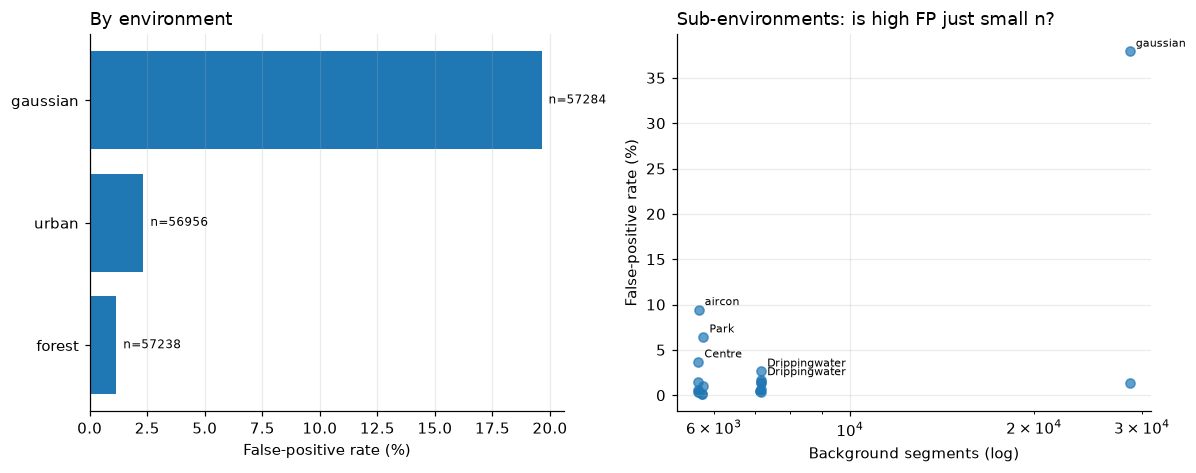

In [30]:
b = bg.copy(); b[env_col] = b[env_col].fillna("unknown")
env = b.groupby(env_col).agg(N=("False positive","size"), FP=("False positive","mean")).assign(FP=lambda d: d.FP*100).sort_values("FP")
fig, axes = plt.subplots(1, 2, figsize=(11,4.4))
axes[0].barh(env.index.astype(str), env.FP)
for i,(fp,n_) in enumerate(zip(env.FP, env.N)): axes[0].text(fp+.3, i, f"n={n_}", va="center", fontsize=8)
axes[0].set_xlabel("False-positive rate (%)"); axes[0].set_title("By environment", loc="left"); axes[0].grid(axis="x", alpha=.25)
axes[1].scatter(bg_result.N, bg_result.FP_pct, alpha=.7); axes[1].set_xscale("log")
for _,r in bg_result.sort_values("FP_pct", ascending=False).head(6).iterrows(): axes[1].annotate(str(r[sub_col]), (r.N, r.FP_pct), xytext=(4,3), textcoords="offset points", fontsize=7)
axes[1].set_xlabel("Background segments (log)"); axes[1].set_ylabel("False-positive rate (%)"); axes[1].set_title("Sub-environments: is high FP just small n?", loc="left"); axes[1].grid(alpha=.25)
plt.tight_layout(); 
# save("fig_background_fp"); 
plt.show()

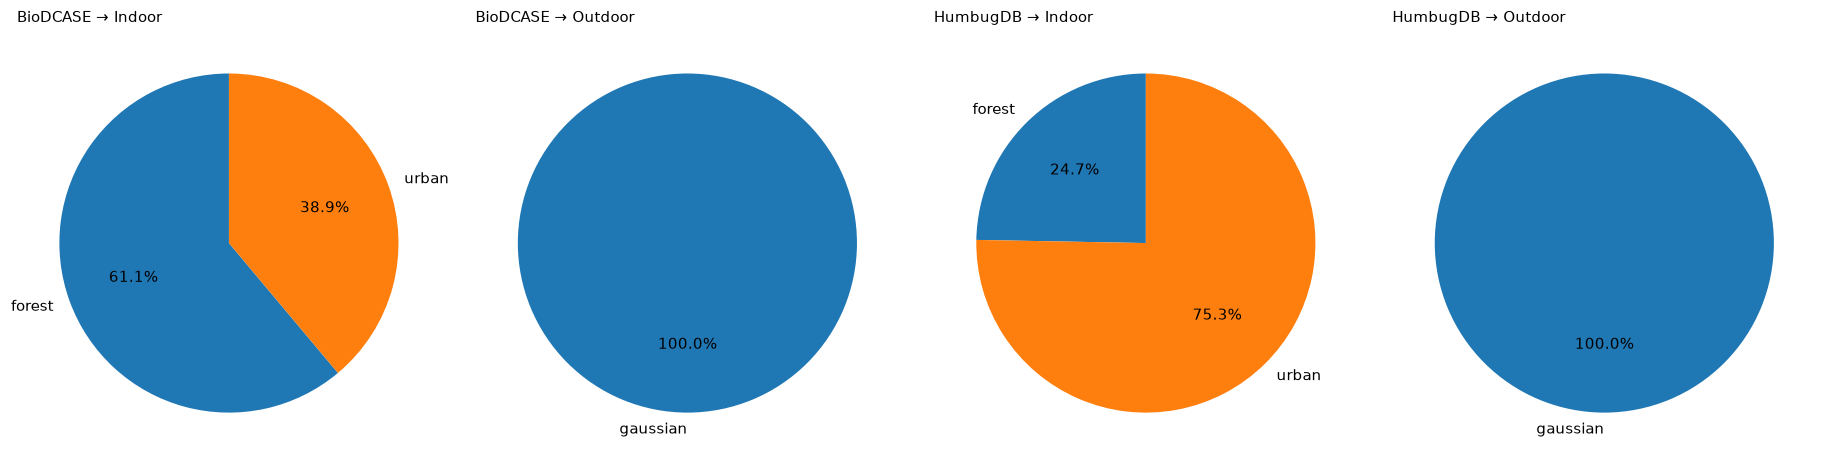

In [ ]:
bg["Setting short"] = bg["Setting"].map(short_setting)
env_setting = bg.groupby(["Setting short", env_col])["False positive"].sum().reset_index(name="FP")
settings = env_setting["Setting short"].unique()

fig, axes = plt.subplots(1, len(settings), figsize=(4.2*len(settings), 4.2))
if len(settings) == 1: axes = [axes]

for ax, st in zip(axes, settings):
    d = env_setting[env_setting["Setting short"] == st]
    ax.pie(d["FP"], labels=d[env_col], autopct="%1.1f%%", startangle=90)
    ax.set_title(st, loc="left", fontsize=10)

plt.tight_layout(); 
# save("fig_background_fp_env_pie_by_setting"); 
plt.show()

In [35]:
env_rate=bg.groupby(["Setting short",env_col])["False positive"].agg(["size","mean"]).reset_index()
env_rate["FP %"]=env_rate["mean"]*100
display(env_rate[["Setting short",env_col,"size","FP %"]].round(2))

,Setting short,metadata_simulation_environment,size,FP %
0,BioDCASE → Indoor,forest,28619,1.00
1,BioDCASE → Indoor,urban,28478,0.64
2,BioDCASE → Outdoor,gaussian,28642,37.93
3,HumbugDB → Indoor,forest,28619,1.32
4,HumbugDB → Indoor,urban,28478,4.03
5,HumbugDB → Outdoor,gaussian,28642,1.35
